In [1]:
# Import các thư viện cần thiết
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

# Cấu hình matplotlib cho tiếng Việt
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

# Tạo thư mục lưu ảnh
RESULTS_DIR = Path('../results/visualizations')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"📁 Thư mục lưu ảnh: {RESULTS_DIR.absolute()}")

📁 Thư mục lưu ảnh: f:\My Drive\Student-Feedback-Sentiment-Analysis\notebook\..\results\visualizations


---
## 🔄 Load Model và Lấy Dữ Liệu Thực Tế

In [2]:
# =============================================================================
# 📦 LOAD PHOBERT BASELINE MODEL VÀ LẤY DỮ LIỆU
# =============================================================================

import torch
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Cấu hình device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Device: {device}")

# Định nghĩa lại model class (GIỐNG HỆT với baseline đã train)
class PhoBERTClassifier(nn.Module):
    def __init__(self, model_name, num_classes, dropout=0.1):
        super(PhoBERTClassifier, self).__init__()
        self.phobert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.phobert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0, :]
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)
        return logits

# Dataset class
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'text': text,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

# Helper function để load state_dict với xử lý prefix
def load_model_safe(model, checkpoint_path, device):
    """
    Load model state_dict với xử lý các trường hợp đặc biệt:
    - Checkpoint có prefix "module." (từ DataParallel)
    - Checkpoint chứa metadata
    """
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

    if isinstance(checkpoint, dict):
        if 'state_dict' in checkpoint:
            state_dict = checkpoint['state_dict']
        elif 'model_state_dict' in checkpoint:
            state_dict = checkpoint['model_state_dict']
        else:
            state_dict = checkpoint
    else:
        state_dict = checkpoint

    new_state_dict = {}
    for k, v in state_dict.items():
        if k.startswith('module.'):
            new_state_dict[k[7:]] = v
        else:
            new_state_dict[k] = v

    model.load_state_dict(new_state_dict)
    return model

# Load tokenizer
print("📥 Loading PhoBERT tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")

# Load test data
print("📂 Loading test data...")
with open('../data/processed/test/sents.txt', 'r', encoding='utf-8') as f:
    test_texts = [line.strip() for line in f.readlines()]

with open('../data/processed/test/sentiments.txt', 'r', encoding='utf-8') as f:
    test_labels = [int(line.strip()) for line in f.readlines()]

print(f"   - Test samples: {len(test_texts)}")

# Tạo dataset và dataloader
test_dataset = SentimentDataset(test_texts, test_labels, tokenizer)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Load PhoBERT Baseline model
print("📥 Loading PhoBERT Baseline model...")
baseline_model = PhoBERTClassifier(model_name="vinai/phobert-base", num_classes=3)
baseline_model = load_model_safe(baseline_model, '../results/PhoBERT_Baseline/phobert_baseline_model.pt', device)
baseline_model = baseline_model.to(device)
baseline_model.eval()
print("   ✅ Model loaded successfully!")

# Inference
print("🔄 Running inference on test set...")
baseline_preds = []
baseline_probs = []
baseline_true = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label']

        outputs = baseline_model(input_ids, attention_mask)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        baseline_preds.extend(preds.cpu().numpy())
        baseline_probs.extend(probs.cpu().numpy())
        baseline_true.extend(labels.numpy())

baseline_preds = np.array(baseline_preds)
baseline_probs = np.array(baseline_probs)
baseline_true = np.array(baseline_true)
baseline_confidences = np.max(baseline_probs, axis=1)

# Tính metrics
print("\n" + "="*60)
print("📊 PHOBERT BASELINE - CLASSIFICATION REPORT")
print("="*60)
class_names = ['Negative', 'Neutral', 'Positive']
report = classification_report(baseline_true, baseline_preds, target_names=class_names, output_dict=True)
print(classification_report(baseline_true, baseline_preds, target_names=class_names))

# Lưu metrics vào dictionary
phobert_baseline_metrics = {
    'classes': class_names,
    'precision': [report['Negative']['precision'], report['Neutral']['precision'], report['Positive']['precision']],
    'recall': [report['Negative']['recall'], report['Neutral']['recall'], report['Positive']['recall']],
    'f1': [report['Negative']['f1-score'], report['Neutral']['f1-score'], report['Positive']['f1-score']]
}

# Confusion matrix
baseline_cm = confusion_matrix(baseline_true, baseline_preds)

# Lưu kết quả tổng hợp
baseline_accuracy = report['accuracy']
baseline_macro_f1 = report['macro avg']['f1-score']

print(f"\n✅ Đã lưu metrics vào: phobert_baseline_metrics")
print(f"✅ Đã lưu confusion matrix vào: baseline_cm")
print(f"✅ Đã lưu confidences vào: baseline_confidences")
print(f"\n📈 Accuracy: {baseline_accuracy:.4f}")
print(f"📈 Macro F1: {baseline_macro_f1:.4f}")

🖥️ Device: cpu
📥 Loading PhoBERT tokenizer...
📂 Loading test data...
   - Test samples: 3166
📥 Loading PhoBERT Baseline model...
   ✅ Model loaded successfully!
🔄 Running inference on test set...


KeyboardInterrupt: 

In [ ]:
# =============================================================================
# 📊 CÁC HÀM TẠO BIỂU ĐỒ
# =============================================================================

def save_figure(fig, filename, dpi=300):
    """Lưu biểu đồ ra file ảnh."""
    filepath = RESULTS_DIR / f"{filename}.png"
    fig.savefig(filepath, dpi=dpi, bbox_inches='tight', facecolor='white', edgecolor='none')
    print(f"✅ Đã lưu: {filepath}")
    return filepath


def plot_per_class_metrics(metrics_dict, model_name, save=True):
    """Vẽ biểu đồ Precision / Recall / F1 theo từng class."""
    classes = metrics_dict['classes']
    precision = metrics_dict['precision']
    recall = metrics_dict['recall']
    f1 = metrics_dict['f1']

    x = np.arange(len(classes))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 6))

    bars1 = ax.bar(x - width, precision, width, label='Precision', color='#4285F4', edgecolor='white')
    bars2 = ax.bar(x, recall, width, label='Recall', color='#EA4335', edgecolor='white')
    bars3 = ax.bar(x + width, f1, width, label='F1-score', color='#34A853', edgecolor='white')

    def add_labels(bars):
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.3f}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3), textcoords="offset points",
                       ha='center', va='bottom', fontsize=9, fontweight='bold')

    add_labels(bars1)
    add_labels(bars2)
    add_labels(bars3)

    ax.set_xlabel('Class', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax.set_title(f'Bảng Precision - Recall - F1 (theo lớp)\n{model_name}', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(classes, fontsize=11)
    ax.legend(loc='upper right', fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    plt.tight_layout()

    if save:
        save_figure(fig, f'per_class_metrics_{model_name.replace(" ", "_").lower()}')
    plt.show()
    return fig, ax


def plot_model_comparison(models_data, save=True):
    """Vẽ biểu đồ so sánh Accuracy & Macro-F1 giữa các model."""
    model_names = models_data['model_names']
    accuracy = models_data['accuracy']
    macro_f1 = models_data['macro_f1']

    x = np.arange(len(model_names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 6))

    bars1 = ax.bar(x - width/2, accuracy, width, label='Accuracy', color='#4285F4', edgecolor='white')
    bars2 = ax.bar(x + width/2, macro_f1, width, label='Macro-F1', color='#FBBC04', edgecolor='white')

    def add_labels(bars):
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.3f}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3), textcoords="offset points",
                       ha='center', va='bottom', fontsize=9, fontweight='bold')

    add_labels(bars1)
    add_labels(bars2)

    ax.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax.set_title('So sánh hiệu suất các Model (Accuracy & Macro-F1)', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=10, rotation=15, ha='right')
    ax.legend(loc='lower right', fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    plt.tight_layout()

    if save:
        save_figure(fig, 'model_comparison_accuracy_f1')
    plt.show()
    return fig, ax


def plot_confusion_matrix(cm, class_names, model_name, normalize=True, save=True):
    """Vẽ Confusion Matrix dạng Heatmap."""
    cm = np.array(cm)

    if normalize:
        cm_display = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        fmt = '.2%'
        title_suffix = '(Normalized)'
    else:
        cm_display = cm
        fmt = 'd'
        title_suffix = '(Count)'

    fig, ax = plt.subplots(figsize=(8, 6))

    sns.heatmap(cm_display, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
                annot_kws={'size': 12, 'fontweight': 'bold'})

    ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
    ax.set_title(f'Confusion Matrix - {model_name}\n{title_suffix}', fontsize=14, fontweight='bold')
    plt.tight_layout()

    if save:
        norm_str = 'normalized' if normalize else 'count'
        save_figure(fig, f'confusion_matrix_{model_name.replace(" ", "_").lower()}_{norm_str}')
    plt.show()
    return fig, ax


def plot_confidence_distribution(confidences, predictions, true_labels, class_names, model_name, save=True):
    """Vẽ biểu đồ phân phối confidence."""
    confidences = np.array(confidences)
    predictions = np.array(predictions)
    true_labels = np.array(true_labels)
    correct_mask = predictions == true_labels

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Correct vs Incorrect
    ax1 = axes[0]
    if np.sum(correct_mask) > 0:
        sns.histplot(confidences[correct_mask], kde=True, color='#34A853',
                    label='Correct', alpha=0.6, bins=30, ax=ax1)
    if np.sum(~correct_mask) > 0:
        sns.histplot(confidences[~correct_mask], kde=True, color='#EA4335',
                    label='Incorrect', alpha=0.6, bins=30, ax=ax1)

    ax1.set_xlabel('Confidence Score', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Count', fontsize=11, fontweight='bold')
    ax1.set_title('Phân phối Confidence\n(Correct vs Incorrect)', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.set_xlim(0, 1)

    # Plot 2: Theo class
    ax2 = axes[1]
    colors = ['#EA4335', '#FBBC04', '#34A853']

    for i, (class_name, color) in enumerate(zip(class_names, colors)):
        mask = predictions == i
        if np.sum(mask) > 0:
            sns.kdeplot(confidences[mask], color=color, label=class_name,
                       linewidth=2, ax=ax2, fill=True, alpha=0.3)

    ax2.set_xlabel('Confidence Score', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Density', fontsize=11, fontweight='bold')
    ax2.set_title('Phân phối Confidence theo Class', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.set_xlim(0, 1)

    fig.suptitle(f'Confidence Distribution - {model_name}', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()

    if save:
        save_figure(fig, f'confidence_distribution_{model_name.replace(" ", "_").lower()}')
    plt.show()
    return fig, axes


print("✅ Đã tải xong các hàm vẽ biểu đồ!")

✅ Đã tải xong các hàm vẽ biểu đồ!


---
## 📈 1. Per-class Precision / Recall / F1

✅ Đã lưu: ..\results\visualizations\per_class_metrics_phobert_baseline.png


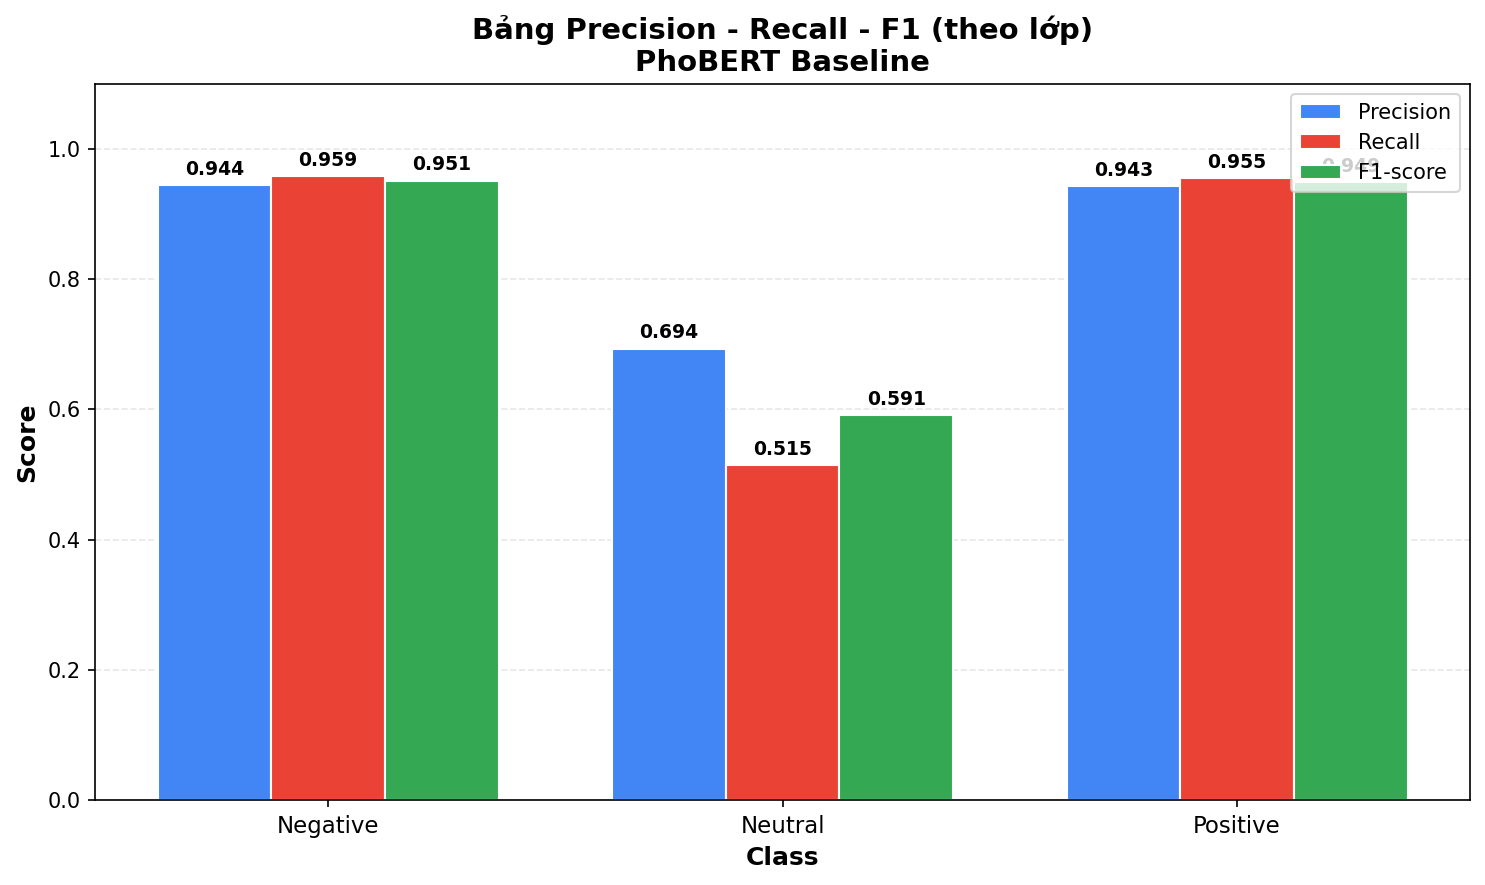

(<Figure size 1500x900 with 1 Axes>,
 <Axes: title={'center': 'Bảng Precision - Recall - F1 (theo lớp)\nPhoBERT Baseline'}, xlabel='Class', ylabel='Score'>)

In [ ]:
# Vẽ biểu đồ Per-class metrics
plot_per_class_metrics(phobert_baseline_metrics, 'PhoBERT Baseline')

---
## 📊 2. Model Comparison

✅ Đã lưu: ..\results\visualizations\model_comparison_accuracy_f1.png


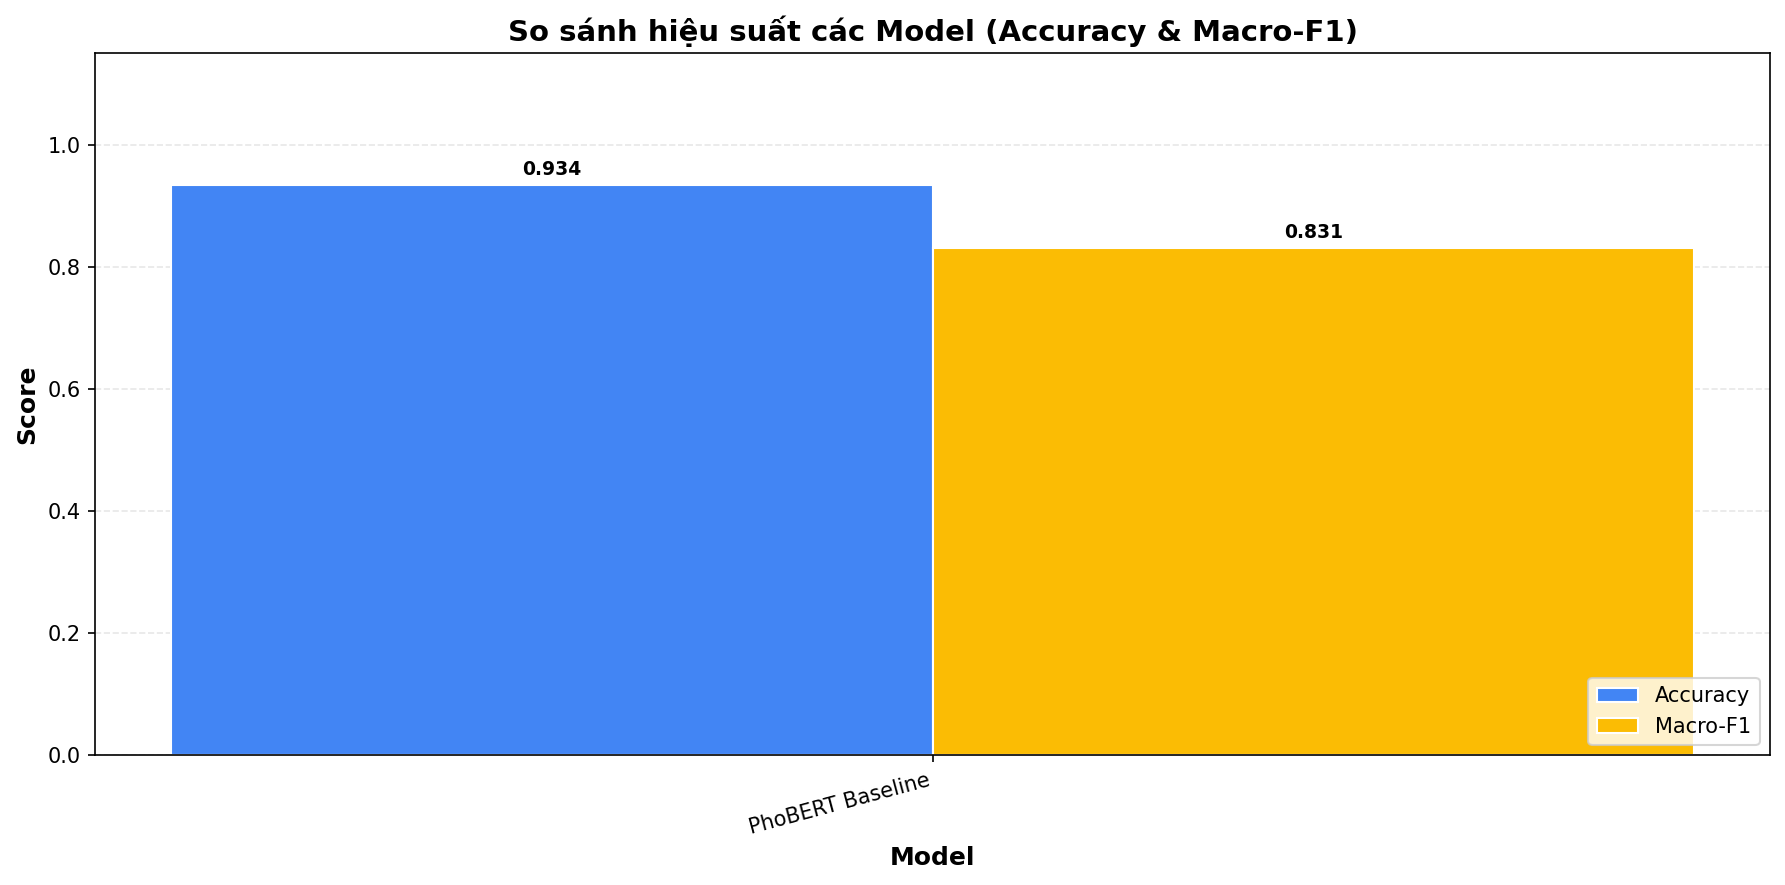

(<Figure size 1800x900 with 1 Axes>,
 <Axes: title={'center': 'So sánh hiệu suất các Model (Accuracy & Macro-F1)'}, xlabel='Model', ylabel='Score'>)

In [ ]:
# Hiện tại chỉ có PhoBERT Baseline
models_comparison = {
    'model_names': ['PhoBERT Baseline'],
    'accuracy': [baseline_accuracy],
    'macro_f1': [baseline_macro_f1]
}
plot_model_comparison(models_comparison)

---
## 🔥 3. Confusion Matrix

✅ Đã lưu: ..\results\visualizations\confusion_matrix_phobert_baseline_normalized.png


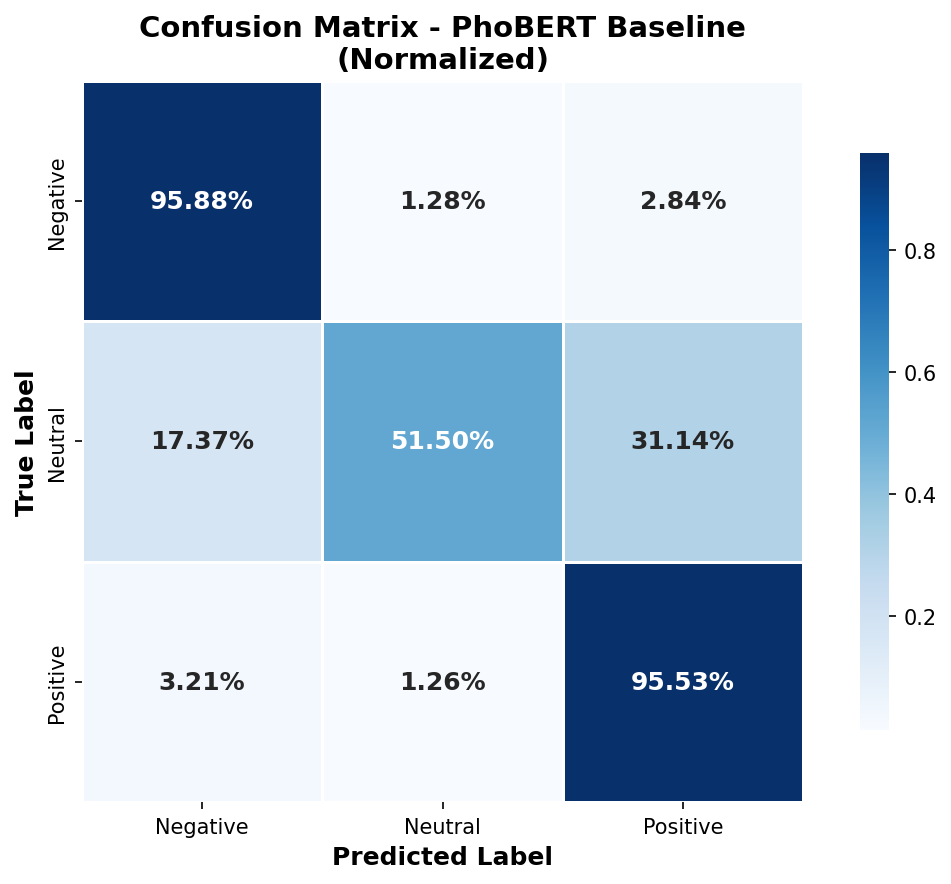

(<Figure size 1200x900 with 2 Axes>,
 <Axes: title={'center': 'Confusion Matrix - PhoBERT Baseline\n(Normalized)'}, xlabel='Predicted Label', ylabel='True Label'>)

In [ ]:
# Confusion Matrix (Normalized)
plot_confusion_matrix(baseline_cm, class_names, 'PhoBERT Baseline', normalize=True)

✅ Đã lưu: ..\results\visualizations\confusion_matrix_phobert_baseline_count.png


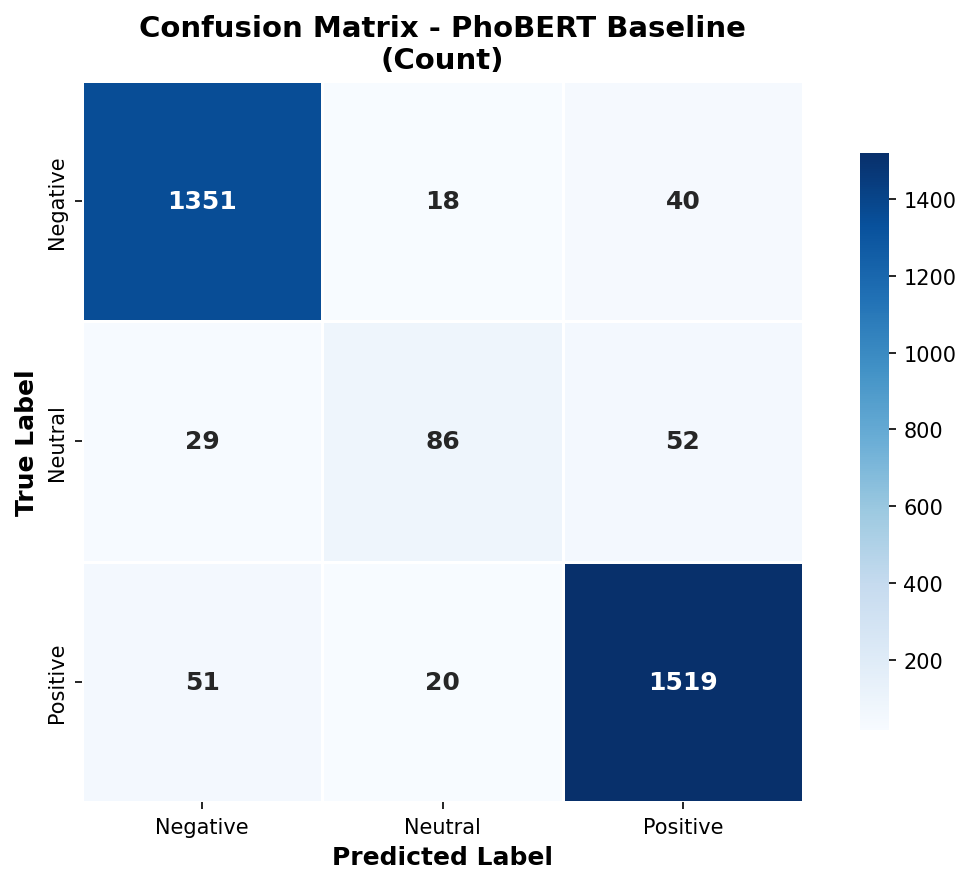

(<Figure size 1200x900 with 2 Axes>,
 <Axes: title={'center': 'Confusion Matrix - PhoBERT Baseline\n(Count)'}, xlabel='Predicted Label', ylabel='True Label'>)

In [ ]:
# Confusion Matrix (Count)
plot_confusion_matrix(baseline_cm, class_names, 'PhoBERT Baseline', normalize=False)

---
## 📉 4. Confidence Distribution

✅ Đã lưu: ..\results\visualizations\confidence_distribution_phobert_baseline.png


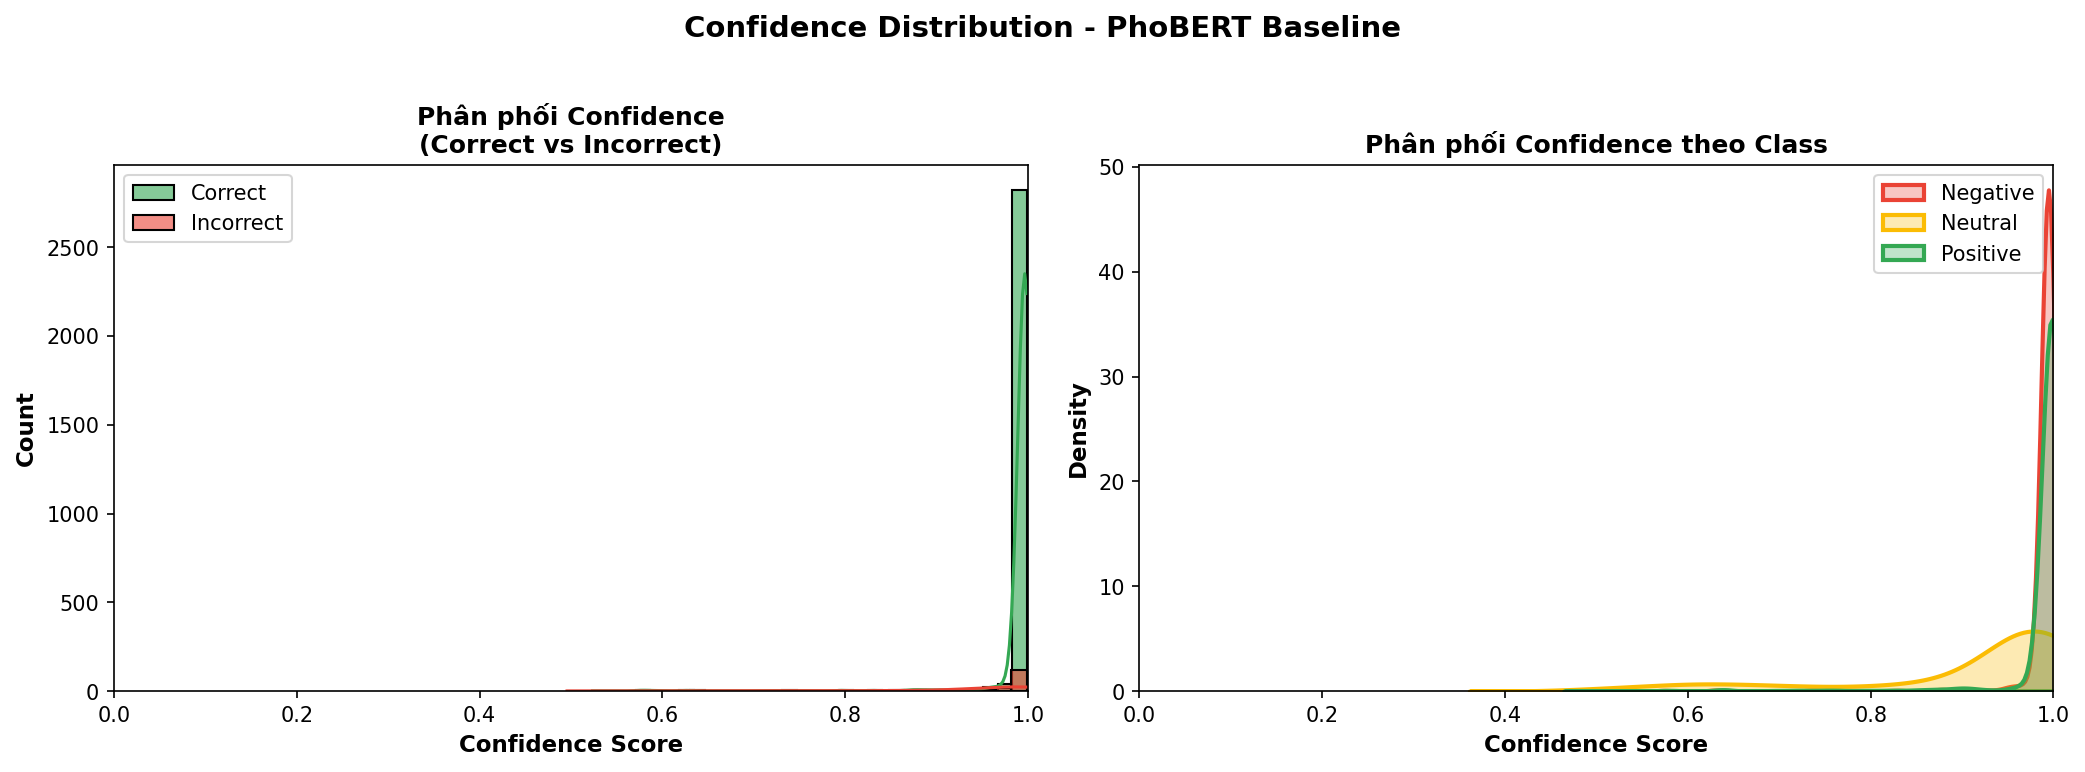

(<Figure size 2100x750 with 2 Axes>,
 array([<Axes: title={'center': 'Phân phối Confidence\n(Correct vs Incorrect)'}, xlabel='Confidence Score', ylabel='Count'>,
        <Axes: title={'center': 'Phân phối Confidence theo Class'}, xlabel='Confidence Score', ylabel='Density'>],
       dtype=object))

In [ ]:
# Phân phối Confidence
plot_confidence_distribution(baseline_confidences, baseline_preds, baseline_true, class_names, 'PhoBERT Baseline')

---
## 📁 Kiểm tra các file ảnh

In [ ]:
# Liệt kê các file ảnh đã lưu
print("📁 Các file ảnh đã lưu:")
print("=" * 50)
if RESULTS_DIR.exists():
    for f in sorted(RESULTS_DIR.glob('*.png')):
        size_kb = f.stat().st_size / 1024
        print(f"  📊 {f.name} ({size_kb:.1f} KB)")
else:
    print("  ⚠️ Chưa có file nào được lưu")

📁 Các file ảnh đã lưu:
  📊 all_models_per_class_comparison.png (131.7 KB)
  📊 confidence_distribution_phobert_baseline.png (179.6 KB)
  📊 confusion_matrix_phobert_baseline_count.png (108.9 KB)
  📊 confusion_matrix_phobert_baseline_normalized.png (124.3 KB)
  📊 error_analysis_lexicon_phobert_baseline.png (206.4 KB)
  📊 model_comparison_accuracy_f1.png (107.2 KB)
  📊 per_class_metrics_phobert_baseline.png (113.4 KB)
